# The action agent, start to finish

This notebook walks through the final agent model from this repository —
the one that decides **where to move next** while reaching goals and
avoiding moving obstacles — and trains it from scratch on expert
demonstrations, then tests it and demonstrates its selection-history
signature.

It is the companion of `Visual-Search/tutorial_visual_search.ipynb`.
The two models share one theory — everything the agent senses, wants,
and remembers is written into a single spatial field, and one readout
selects the action — realized in two very different bodies:

| | visual search | action agent |
| --- | --- | --- |
| coordinate frame | retinotopic pixels | 360 rays around the agent |
| bottom-up source | color/shape contrast maps | obstacle sense (proximity + looming) |
| top-down source | goal-weighted color evidence | goal field (gain x cosine geometry) |
| history source | target/distractor memory traces | remembered goal-location field |
| readout | softmax over items -> a saccade | planner network -> a movement |

**Input and output.** Each step the agent receives: two consecutive
LiDAR scans (360 distances each), the vector to the visible goal, and
the vector to its remembered goal location. It returns a 2D movement.

**Before running:** generate the demonstrations once:

    python3 expert_goal.py --num_features 360 --num_episodes 20 \
      --max_steps_per_episode 3000 --record_every 5 --goal_free_steps 0 \
      --goal_bias none --output dataset/data_goal_unbiased_360.csv

Needs `numpy`, `pandas`, `matplotlib`, `torch`. Training takes under a
minute; the evaluation cells a few minutes each.

In [1]:
import math
import random
from types import SimpleNamespace

import numpy as np
import matplotlib.pyplot as plt
import torch

from model.goal_es2 import GoalEs2Model
from environment import (GOAL_RADIUS, CollisionTracker,
                                lidar_scan, make_world, sample_goal)

# publication style, matched to tutorial_visual_search.ipynb:
# despined axes, frameless legends, one shared palette
plt.rcParams.update({
    "axes.spines.top": False, "axes.spines.right": False,
    "axes.labelsize": 12, "axes.titlesize": 11, "font.size": 11,
    "legend.frameon": False, "legend.fontsize": 10,
    "xtick.labelsize": 10, "ytick.labelsize": 10,
    "lines.linewidth": 1.6, "figure.dpi": 110,
})
C_ES2, C_MLP, C_TRF = "#2233aa", "#cc7722", "#118844"
C_GOAL, C_HAZARD, C_GRAY = "#118844", "#aa2222", "#888888"

torch.manual_seed(0)
random.seed(0)
W = H = 800

## 1. The model, with a diagram

The equation, in words. For each of 360 directions around the agent:

    field(direction) = obstacle sense(direction)
                       + goal field(direction)
                       + beta_H x history field(direction)

    movement = planner(field)

Every source flows into one ego-centered field; a small network reads
the field out as a movement. Two honest notes:

- **The channel gains are curves, not scalars.** In the search model
  each channel has one readable gain (`g_C`, `g_F`). Here the goal and
  history fields carry a learned **gain-vs-distance curve** (a tiny
  MLP), and the obstacle pathway a learned per-ray sensitivity `k`
  inside a fixed sigmoid. All three are the same kind of object — a
  psychophysical transfer function from a physical variable to signal
  strength: the obstacle curve transduces *physics* (distance, approach
  -> perceived urgency), the goal and history curves transduce
  *relevance* (distance -> pull). Comparing channels means comparing
  curves, not numbers.
- **There is no attention window here, and none in the search model
  either.** What the original ES2 paper called an "attention field" is
  the psychophysical transform above — part of building the sensory
  field, not a gate over a finished one. Recognizing that is what let
  the search model drop its window.

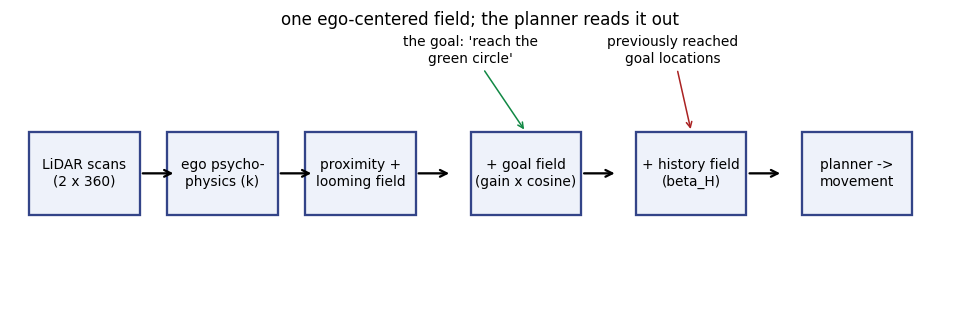

In [2]:
fig, ax = plt.subplots(figsize=(11, 3.2))
boxes = [(0.02, "LiDAR scans\n(2 x 360)"),
         (0.17, "ego psycho-\nphysics (k)"),
         (0.32, "proximity +\nlooming field"),
         (0.50, "+ goal field\n(gain x cosine)"),
         (0.68, "+ history field\n(beta_H)"),
         (0.86, "planner ->\nmovement")]
for x, label in boxes:
    ax.add_patch(plt.Rectangle((x, 0.35), 0.12, 0.32, fc="#eef2fa",
                               ec="#334488", lw=1.5))
    ax.text(x + 0.06, 0.51, label, ha="center", va="center", fontsize=9)
for x, _ in boxes[:-1]:
    ax.annotate("", xy=(x + 0.16, 0.51), xytext=(x + 0.12, 0.51),
                arrowprops=dict(arrowstyle="->", lw=1.5))
ax.annotate("the goal: 'reach the\ngreen circle'", xy=(0.56, 0.67),
            xytext=(0.50, 0.94), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#118844"))
ax.annotate("previously reached\ngoal locations", xy=(0.74, 0.67),
            xytext=(0.72, 0.94), ha="center", fontsize=9,
            arrowprops=dict(arrowstyle="->", color="#aa2222"))
ax.set_xlim(0, 1.02); ax.set_ylim(0, 1.05); ax.axis("off")
plt.title("one ego-centered field; the planner reads it out")
plt.show()

## 2. Building it piece by piece

### 2a. From distances to perceived closeness

The agent senses the world as 360 LiDAR rays. The first stage is pure
psychophysics: each distance passes through a sigmoid with learned
sensitivity `k`,

    sense(d) = 2 * (1 - sigmoid(k * d))    in (0, 2)

so **near is strong, far is weak**, saturating at both ends — a
Weber-style compression of physical distance into signal. Below: an
example world, its raw scan, and the transformed scan (`k` at its
initialization; training tunes one `k` per ray).

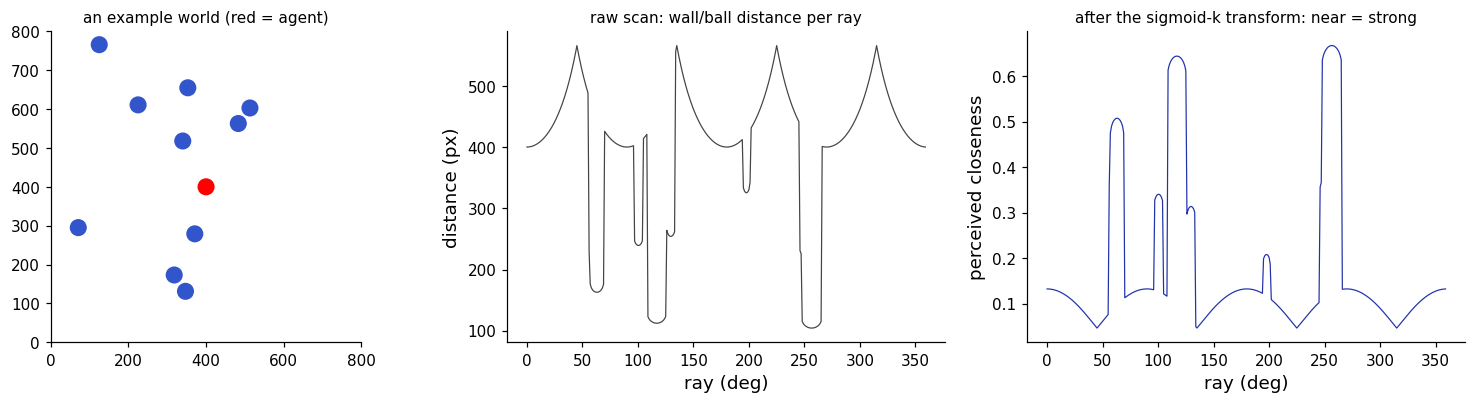

In [3]:
player, balls = make_world(10, W, H)
distances, _ = lidar_scan(player, balls, W, H, 360)
demo = GoalEs2Model(num_features=360)          # untrained: for the transform shape
with torch.no_grad():
    sensed = demo.spatial_sense_block.sigmoid(torch.tensor(distances)).numpy()

fig, axes = plt.subplots(1, 3, figsize=(14, 3.8))
axes[0].add_patch(plt.Circle((player.x, player.y), player.radius, color="red"))
for b in balls:
    if b is not player:
        axes[0].add_patch(plt.Circle((b.x, b.y), b.radius, color="#3355cc"))
axes[0].set_xlim(0, W); axes[0].set_ylim(0, H); axes[0].set_aspect(1)
axes[0].set_title("an example world (red = agent)", fontsize=10)
axes[1].plot(distances, color="#444444", lw=0.8)
axes[1].set_xlabel("ray (deg)"); axes[1].set_ylabel("distance (px)")
axes[1].set_title("raw scan: wall/ball distance per ray", fontsize=10)
axes[2].plot(sensed, color=C_ES2, lw=0.8)
axes[2].set_xlabel("ray (deg)"); axes[2].set_ylabel("perceived closeness")
axes[2].set_title("after the sigmoid-k transform: near = strong", fontsize=10)
plt.tight_layout()
plt.show()

### 2b. The obstacle field: proximity and looming

One number per direction has to answer two questions: *how close* is
something, and is it *approaching*? The obstacle field answers both by
summing two channels, each with one learned scalar gain:

    obstacle(direction) = g_C * closeness_now
                        + g_L * (closeness_now - closeness_before) * closeness_now

- **Proximity** (`g_C * closeness_now`): how close something is right
  now — a static standoff signal, near = strong.
- **Looming** (`g_L * (closeness_now - closeness_before) * closeness_now`):
  the change in closeness (approach), gated by current closeness so that
  approach only counts where something is already near.

The two are co-equal evidence channels combined additively — the same
shape as the search model's `g_C*color + g_F*shape` — rather than a
single gated product, and each gain is one interpretable scalar rather
than an MLP. Cloning the expert settles on `g_C ~ 1.2` and `g_L ~ 0.02`:
in this arena current closeness carries almost the whole task, and the
change signal is nearly redundant once proximity is available. (The plot
below uses the untrained model, `g_C = g_L = 1`, so both channels show at
equal weight; training is what drives `g_L` down.)

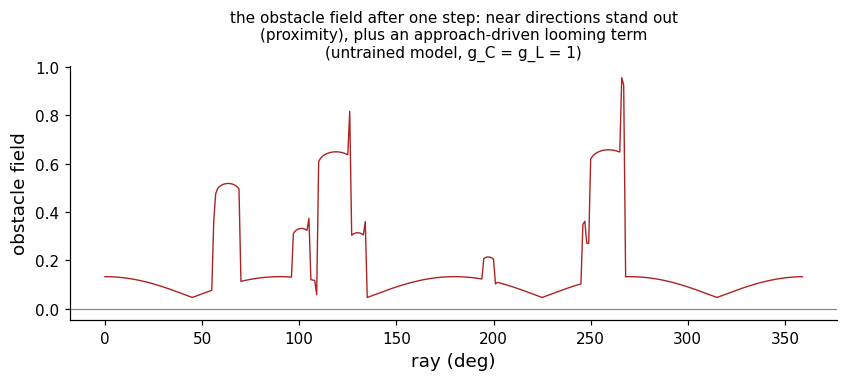

In [4]:
for b in balls:
    if b is not player:
        b.move()
distances2, _ = lidar_scan(player, balls, W, H, 360)
with torch.no_grad():
    obs_field = demo.spatial_sense_block(
        torch.tensor(distances + distances2, dtype=torch.float32).unsqueeze(0)
    )[0].numpy()

plt.figure(figsize=(9, 3))
plt.plot(obs_field, color=C_HAZARD, lw=0.9)
plt.axhline(0, color=C_GRAY, lw=0.8)
plt.xlabel("ray (deg)"); plt.ylabel("obstacle field")
plt.title("the obstacle field after one step: near directions stand out\n"
          "(proximity), plus an approach-driven looming term\n"
          "(untrained model, g_C = g_L = 1)",
          fontsize=10)
plt.show()

### 2c. The goal field: a pull pattern over directions

The goal is one location; the field turns it into a value for every
one of the 360 ray directions:

    goal_field(ray) = gain(goal distance) * cos(ray - direction to the goal)

Two factors, two jobs:

- **The cosine is the geometry of pull.** "Direction to the goal" is
  the angle of the agent-to-goal vector (what navigators call the
  bearing) — nothing to do with which way the agent is currently
  moving. Each ray gets the cosine of the angle between *that ray*
  and the agent-to-goal direction: +1 on the ray pointing straight at
  the goal, fading to 0 sideways, −1 directly behind. Move the agent
  and the whole pattern rotates to keep its peak on the goal.
- **The gain sets how hard the pattern pulls.** It is one learned
  number (a tiny MLP of goal distance) multiplying the whole cosine
  pattern — the relevance of a goal at that distance. What training
  actually makes of it (Sec. 4): near-zero magnitude inside ~70 px —
  the pull releases as the agent arrives — and constant strength at
  any farther distance. (Its learned sign is arbitrary: the planner
  downstream learns the matching convention, so magnitude is what
  carries meaning.)

Below: one fixed goal and three hypothetical agent positions. Each
position has its own bearing to the goal, so each gets a cosine
pattern peaking at a different ray; their distances set the gain.


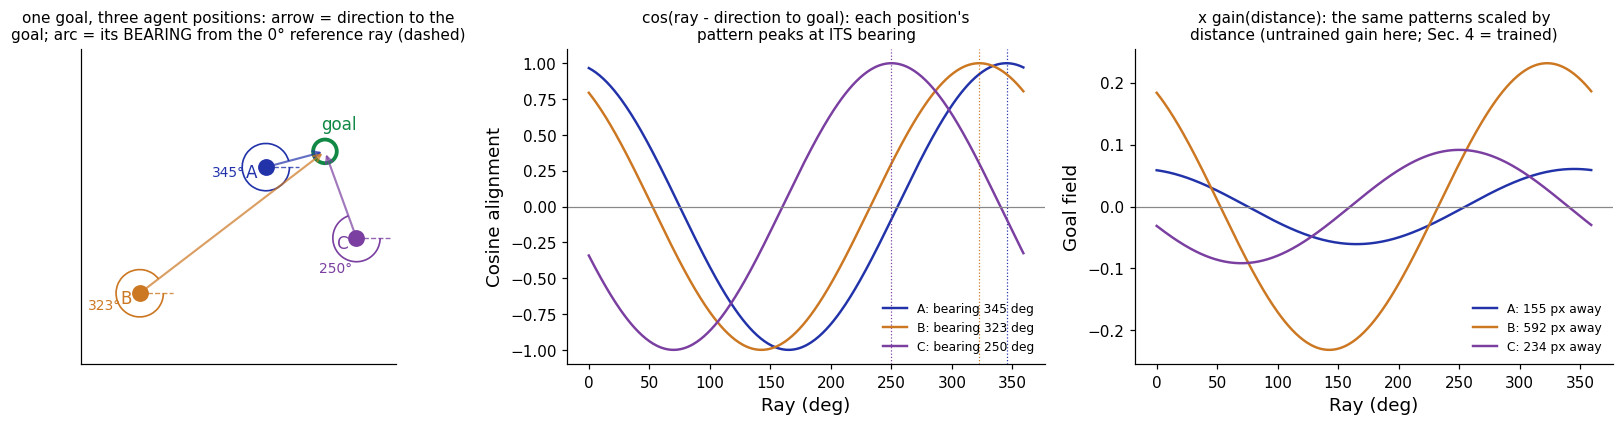

In [5]:
from matplotlib.patches import Arc

GOAL = (620, 260)
agents = {"A (near)": (470, 300), "B (far)": (150, 620),
          "C (other side)": (700, 480)}
acolors = {"A (near)": C_ES2, "B (far)": C_MLP, "C (other side)": "#7a3fa0"}

fig, axes = plt.subplots(1, 3, figsize=(15, 4.0))
ax = axes[0]
ax.add_patch(plt.Circle(GOAL, 30, fc="none", ec=C_GOAL, lw=2.5))
ax.annotate("goal", GOAL, (GOAL[0] - 10, GOAL[1] - 55), color=C_GOAL,
            fontsize=11)
for name, (x, y) in agents.items():
    ax.plot(x, y, "o", color=acolors[name], ms=10)
    ax.annotate("", xy=GOAL, xytext=(x, y),
                arrowprops=dict(arrowstyle="->", color=acolors[name],
                                lw=1.4, alpha=0.7))
    ax.annotate(name.split()[0], (x, y), (x - 50, y + 25),
                color=acolors[name], fontsize=11)
    # the BEARING: the angle from the 0-deg reference ray (+x, dashed)
    # around to the agent-to-goal direction
    b = math.degrees(math.atan2(GOAL[1] - y, GOAL[0] - x)) % 360
    ax.plot([x, x + 85], [y, y], color=acolors[name], lw=0.9, ls="--",
            alpha=0.8)
    ax.add_patch(Arc((x, y), 120, 120, angle=0, theta1=0, theta2=b,
                     color=acolors[name], lw=1.1))
    la = math.radians(b / 2)
    ax.annotate(f"{b:.0f}°", (x + 95 * math.cos(la), y + 95 * math.sin(la)),
                color=acolors[name], fontsize=9, ha="center", va="center")
ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_aspect(1)
ax.invert_yaxis()
ax.set_title("one goal, three agent positions: arrow = direction to the\n"
             "goal; arc = its BEARING from the 0° reference ray (dashed)",
             fontsize=10)
ax.set_xticks([]); ax.set_yticks([])

rays = np.arange(360)
for name, (x, y) in agents.items():
    dx, dy = GOAL[0] - x, GOAL[1] - y
    dist = math.hypot(dx, dy)
    bearing = math.degrees(math.atan2(dy, dx)) % 360
    cosine = np.cos(np.deg2rad(rays - bearing))
    axes[1].plot(rays, cosine, color=acolors[name], lw=1.6,
                 label=f"{name.split()[0]}: bearing {bearing:.0f} deg")
    axes[1].axvline(bearing, color=acolors[name], lw=0.8, ls=":")
    with torch.no_grad():
        g = demo.goal_gain(torch.tensor([[dist / demo.sensing_range]]))
    axes[2].plot(rays, (g.item() * cosine), color=acolors[name], lw=1.6,
                 label=f"{name.split()[0]}: {dist:.0f} px away")
axes[1].axhline(0, color=C_GRAY, lw=0.8)
axes[1].set_xlabel("Ray (deg)"); axes[1].set_ylabel("Cosine alignment")
axes[1].set_title("cos(ray - direction to goal): each position's\n"
                  "pattern peaks at ITS bearing", fontsize=10)
axes[1].legend(fontsize=8)
axes[2].axhline(0, color=C_GRAY, lw=0.8)
axes[2].set_xlabel("Ray (deg)"); axes[2].set_ylabel("Goal field")
axes[2].set_title("x gain(distance): the same patterns scaled by\n"
                  "distance (untrained gain here; Sec. 4 = trained)",
                  fontsize=10)
axes[2].legend(fontsize=8)
plt.tight_layout()
plt.show()


### 2d. The history field: the same pull, from remembered locations

The history field reuses the **identical gain-x-cosine construction of
2c** — but its source is not a visible goal, it is **memory**: a leaky
accumulator over an 8x8 grid of the arena in world coordinates. Every
time a goal appears, all weights decay and the goal's cell gets a
boost:

    W *= (1 - eta_H);   W[cell(goal)] += eta_H

`eta_H` is the learning rate and sets the horizon (~1/eta_H goals
remembered); a one-back "previous goal" memory is just `eta_H = 1`.
Storage is **allocentric** — the map is about the world, not about
where the agent stands.

The readout treats **every cell as a faint goal**. For one cell, the
construction is exactly 2c's: the direction from the agent to the
cell's center gives the bearing, the cosine pattern peaks there, and
the SAME `gain(distance)` curve scales it — then everything is
weighted by the cell's accumulated mass `W[c]`. Do that for all 64
cells and sum, and one scalar `beta_H` sets the overall strength:

    history_field = beta_H * sum_c W[c] * gain(dist to c) * cos(ray - direction to c)

So the field pulls toward the memory's mass wherever it is piled up —
a single cell only in the limit where all the mass is in one place.
`eta_H` = how fast memory updates, `W` = what is remembered, `beta_H`
= how much it biases behavior — the exact analog of the search
model's `eta_T` / `h_T` / `beta_T`. One precedence rule: **a visible
goal overrides history** — the history field enters the sum only when
no goal is on screen. (The accumulator lives inside the model:
`update_memory` / `history_field` in `model/goal_es2.py`; cloning
never touches it, so adding or fitting the memory needs no
retraining.)

Below, left to right: the grid after 12 goals biased toward the left;
the 2c geometry applied to ONE example cell (the heaviest); every
cell's weighted contribution; and their sum — the ACTUAL history
field at this agent position.


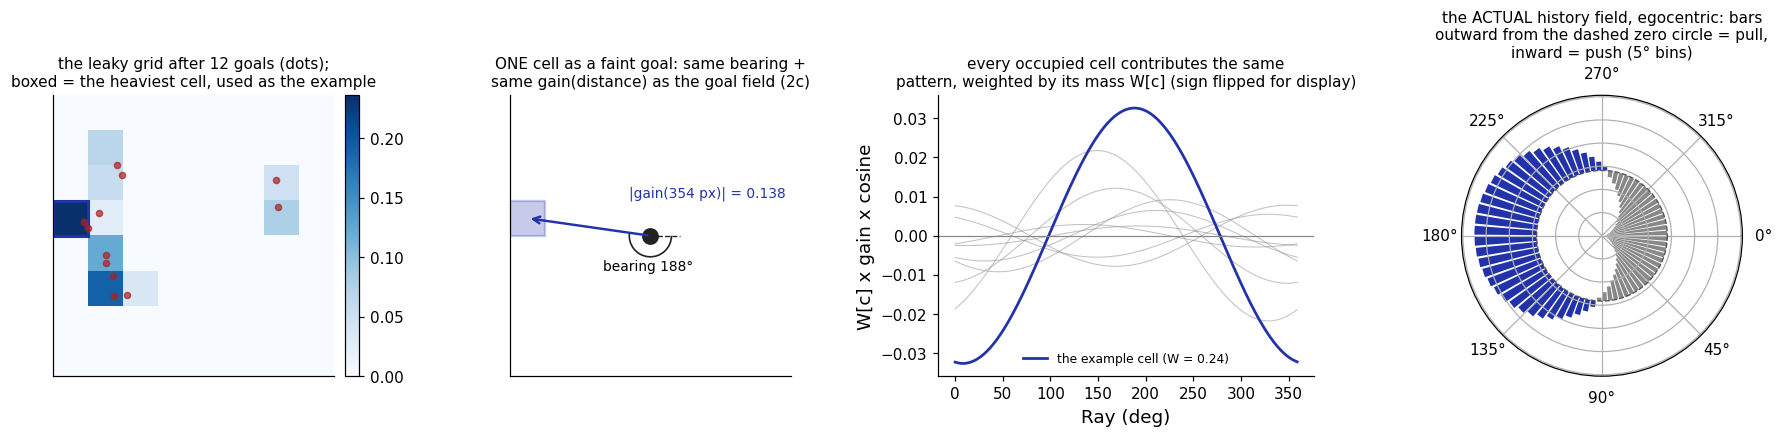

In [6]:
from matplotlib.patches import Arc, Rectangle

rng = random.Random(7)
demo.eta_H = 0.15
demo.reset_memory(W, H)
goals_demo = []
for _ in range(12):                        # 70% in the LEFT wedge
    ecc = rng.uniform(250, 330)
    if rng.random() < 0.7:
        a = math.pi + rng.uniform(-math.pi / 4, math.pi / 4)
    else:
        a = rng.uniform(-math.pi / 4, math.pi / 4)
    g = (W / 2 + ecc * math.cos(a), H / 2 + ecc * math.sin(a))
    goals_demo.append(g)
    demo.update_memory(g)

memory = demo.memory
centers = demo._centers
BETA_DEMO = 0.2
px, py = W / 2, H / 2                      # the agent, at center
k_star = int(memory.argmax())              # the heaviest cell: the example
cx, cy = centers[k_star].tolist()

fig, axes = plt.subplots(1, 4, figsize=(17, 4.0))

ax = axes[0]
im = ax.imshow(memory.reshape(8, 8), cmap="Blues", origin="upper",
               extent=[0, W, H, 0])
for g in goals_demo:
    ax.plot(g[0], g[1], "o", ms=4, color=C_HAZARD, alpha=0.7)
ax.add_patch(Rectangle((cx - 50, cy - 50), 100, 100, fc="none",
                       ec=C_ES2, lw=2))
ax.set_title("the leaky grid after 12 goals (dots);\n"
             "boxed = the heaviest cell, used as the example", fontsize=10)
ax.set_xticks([]); ax.set_yticks([])
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.03)

# --- one cell, the 2c geometry: bearing arc + gain(distance) ---
ax = axes[1]
dist = math.hypot(cx - px, cy - py)
b = math.degrees(math.atan2(cy - py, cx - px)) % 360
ax.plot(px, py, "o", color="#222222", ms=10)
ax.add_patch(Rectangle((cx - 50, cy - 50), 100, 100, fc=C_ES2, alpha=0.25,
                       ec=C_ES2, lw=1.5))
ax.annotate("", xy=(cx, cy), xytext=(px, py),
            arrowprops=dict(arrowstyle="->", color=C_ES2, lw=1.6))
ax.plot([px, px + 85], [py, py], color="#222222", lw=0.9, ls="--")
ax.add_patch(Arc((px, py), 120, 120, angle=0, theta1=0, theta2=b,
                 color="#222222", lw=1.1))
la = math.radians(b / 2)
ax.annotate(f"bearing {b:.0f}°", (px + 100 * math.cos(la),
                                  py + 100 * math.sin(la)),
            fontsize=9, ha="center")
with torch.no_grad():
    g_here = demo.goal_gain(torch.tensor([[dist / demo.sensing_range]])).item()
# the untrained gain's sign is arbitrary (the planner learns the
# convention - see 2c); flip for display so pull plots as positive
SFLIP = -1.0 if g_here < 0 else 1.0
ax.annotate(f"|gain({dist:.0f} px)| = {abs(g_here):.3f}",
            (px - 60, py - 110), color=C_ES2, fontsize=9, ha="left")
ax.set_xlim(0, W); ax.set_ylim(0, H); ax.set_aspect(1); ax.invert_yaxis()
ax.set_xticks([]); ax.set_yticks([])
ax.set_title("ONE cell as a faint goal: same bearing +\n"
             "same gain(distance) as the goal field (2c)", fontsize=10)

# --- every cell's weighted contribution, then the sum ---
rays = np.arange(360)
vec = centers - torch.tensor([px, py], dtype=torch.float32)
with torch.no_grad():
    Gall = demo.geometric_field(vec, demo.goal_gain)       # (64, 360)
contrib = SFLIP * (memory.unsqueeze(1) * Gall).numpy()
ax = axes[2]
for c in range(64):
    if memory[c] > 0 and c != k_star:
        ax.plot(rays, contrib[c], color=C_GRAY, lw=0.7, alpha=0.5)
ax.plot(rays, contrib[k_star], color=C_ES2, lw=1.8,
        label=f"the example cell (W = {memory[k_star]:.2f})")
ax.axhline(0, color=C_GRAY, lw=0.8)
ax.set_xlabel("Ray (deg)"); ax.set_ylabel("W[c] x gain x cosine")
ax.set_title("every occupied cell contributes the same\n"
             "pattern, weighted by its mass W[c] (sign flipped for display)",
             fontsize=10)
ax.legend(fontsize=8)


def polar_hist(ax, v, col, bin_deg=5):
    """Circular histogram of a 360-ray field: 5-degree bins (the bin's
    extreme value), bars OUTWARD from the dashed zero circle = positive
    (pull), INWARD = negative (push)."""
    nb_ = 360 // bin_deg
    binned = np.zeros(nb_)
    for k in range(nb_):
        seg = v[k * bin_deg:(k + 1) * bin_deg]
        binned[k] = seg[np.argmax(np.abs(seg))]
    r0 = 1.05 * np.abs(v).max() + 1e-9
    ang_ = np.deg2rad(np.arange(nb_) * bin_deg + bin_deg / 2)
    wd_ = np.deg2rad(bin_deg) * 0.8
    pos, neg = binned >= 0, binned < 0
    ax.bar(ang_[pos], binned[pos], width=wd_, bottom=r0, color=col)
    ax.bar(ang_[neg], -binned[neg], width=wd_,
           bottom=r0 + binned[neg], color=C_GRAY)
    th = np.linspace(0, 2 * np.pi, 200)
    ax.plot(th, np.full_like(th, r0), ls="--", color="#555555", lw=0.9)
    ax.set_ylim(0, 2.15 * r0)
    ax.set_theta_zero_location("E"); ax.set_theta_direction(-1)
    ax.set_yticklabels([])

axes[3].remove()
ax = fig.add_subplot(1, 4, 4, projection="polar")
hf = SFLIP * BETA_DEMO * demo.history_field((px, py))[0].numpy()
polar_hist(ax, hf, C_ES2)
ax.set_title("the ACTUAL history field, egocentric: bars\n"
             "outward from the dashed zero circle = pull,\n"
             "inward = push (5° bins)", fontsize=10)
plt.tight_layout()
plt.show()


### 2e. The actual fields, one scene

2a-2d showed the pieces. Here they are computed for real, in one
scene: the example world of 2a, one visible goal, and 2d's memory —
each field exactly as the model computes it, and their sum, the
**priority field the planner reads** — drawn the way the agent has
them: **egocentric roses**, the agent at the center, one value per
ray direction (0° = east, angles clockwise to match the arena's
screen coordinates). The colored lobe is the positive part of the
field (pull toward those directions), the gray lobe the negative part
(push away); the radius is the magnitude. These fields are 1-D over
direction — a 360° panorama, not a 2-D map: distance lives in the
lobes' size, not in a radial axis. (Weights still untrained here,
so the shapes, not the magnitudes, are the point — and the goal and
history lobes are sign-flipped for display as in 2d, so pull points
at the source; Sec. 4-5 show the
trained model acting on the trained version of this sum. And by the
precedence rule, with a goal visible the history row would actually
be gated off — it is drawn here to show all three at once.)


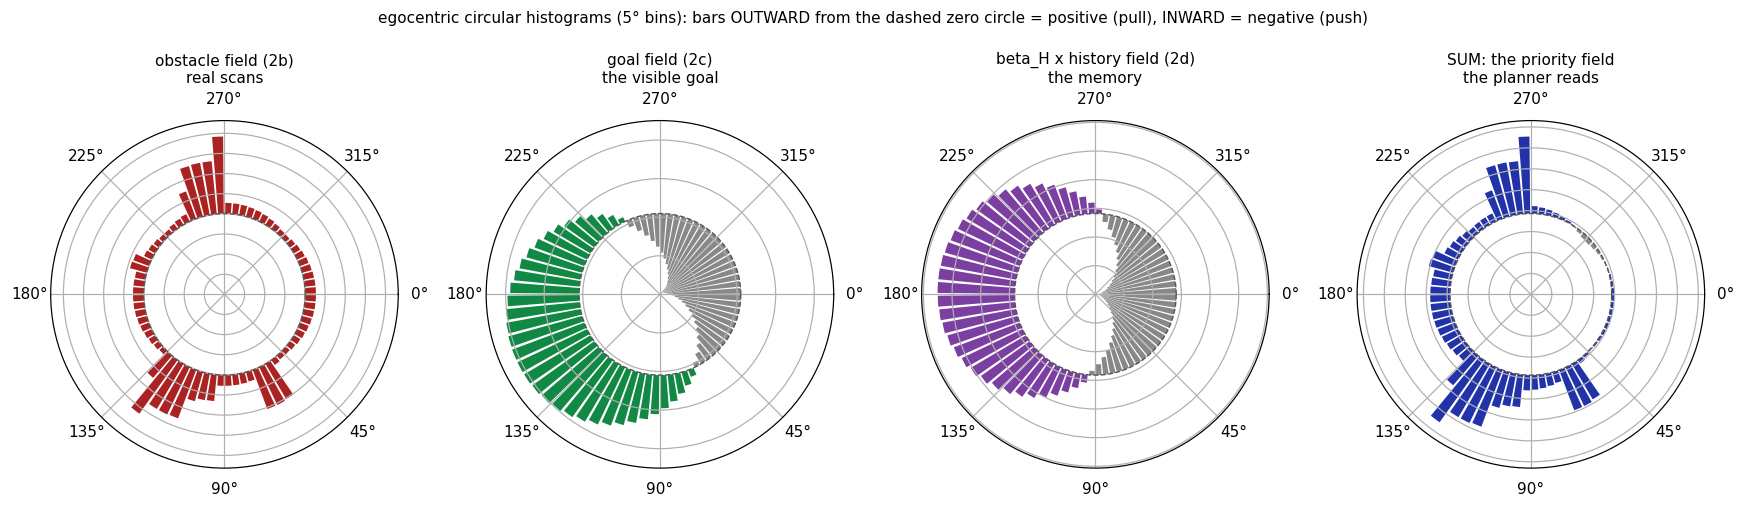

In [7]:
goal_vec = (goals_demo[-1][0] - px, goals_demo[-1][1] - py)
obs = torch.tensor(distances + distances2 + list(goal_vec),
                   dtype=torch.float32).unsqueeze(0)
with torch.no_grad():
    f_obs, f_goal = demo.compute_fields(obs)
# SFLIP (from 2d): the untrained gain's sign is arbitrary; flip the
# gain-based fields for display so pull lobes point at their sources
f_goal = SFLIP * f_goal
f_hist = SFLIP * BETA_DEMO * demo.history_field((px, py))
f_sum = f_obs + f_goal + f_hist

fig, axes = plt.subplots(1, 4, figsize=(16, 4.4),
                         subplot_kw=dict(projection="polar"))
for ax, f, name, col in [
        (axes[0], f_obs, "obstacle field (2b)\nreal scans", C_HAZARD),
        (axes[1], f_goal, "goal field (2c)\nthe visible goal", C_GOAL),
        (axes[2], f_hist, "beta_H x history field (2d)\nthe memory", "#7a3fa0"),
        (axes[3], f_sum, "SUM: the priority field\nthe planner reads", C_ES2)]:
    polar_hist(ax, f[0].numpy(), col)
    ax.set_title(name, fontsize=10)
plt.suptitle("egocentric circular histograms (5° bins): bars OUTWARD from "
             "the dashed zero circle = positive (pull), INWARD = negative "
             "(push)", fontsize=10, y=1.02)
plt.tight_layout()
plt.show()


## 3. The whole model in five lines

Not a re-implementation — the actual forward pass, imported from
`model/goal_es2.py`:

In [8]:
import inspect
print(inspect.getsource(GoalEs2Model.compute_fields))
print(inspect.getsource(GoalEs2Model.forward))

    def compute_fields(self, input):
        scan_input = input[:, : 2 * self.num_features]
        goal = input[:, 2 * self.num_features :]

        obstacle_field = self.spatial_sense_block(scan_input)
        goal_field = self.geometric_field(goal, self.goal_gain)
        return obstacle_field, goal_field

    def forward(self, input, history_field=None):
        obstacle_field, goal_field = self.compute_fields(input)
        field = obstacle_field + goal_field
        if history_field is not None:
            field = field + self.beta_H * history_field
        return self.sense_action_layers(field)



## 4. The trained model

The dataset holds 12,000 recorded steps of a scripted expert playing
the continuous task — reach the green goal, dodge the balls, a new
goal spawns on arrival (1,316 goals, 0 collisions; 65.8 goals/min).
The model of record is cloned from it — match the expert's movement at
every recorded step by gradient descent, the same mini-batch recipe as
every model in this repository (batch 64, Adam, MSE, 500 epochs) — by
`train_goal_es2.py`. **We do not retrain in the notebook; we load the
resulting checkpoint** (`pretrained/goal_es2.pth`) and show its recorded
cloning-loss curve.

**History is disabled during training** (`beta_H` frozen at 0) — this
is the model of record. The reason is principled, not incidental, and
Section 7 is about it: this expert never uses its memory, so cloning
can attribute nothing to the history channel; leaving the channel
free only lets it chase noise (it fits better in-sample and behaves
worse in rollout — the record for that ablation is in
`RESULTS_goal_es2.md`).

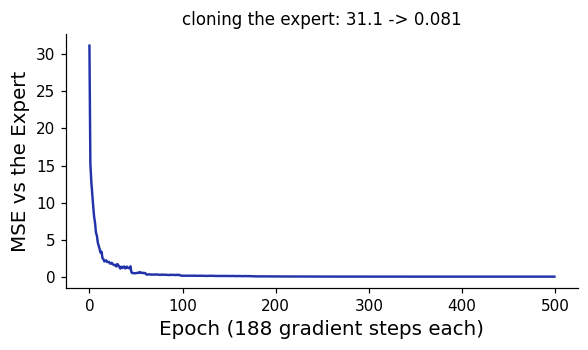

In [9]:
import csv

# The model of record is already cloned from the expert (train_goal_es2.py);
# load its weights rather than retraining in the notebook.
model = GoalEs2Model(num_features=360)
model.load_state_dict(torch.load("pretrained/goal_es2.pth",
                                 map_location="cpu", weights_only=True))
model.eval()

# its recorded cloning-loss curve (same 500-epoch run as the baselines below)
with open("results_compare/loss_goal_es2.csv") as f:
    losses = [float(r["loss"]) for r in csv.DictReader(f)]

plt.figure(figsize=(6, 3))
plt.plot(losses, color=C_ES2)
plt.xlabel("Epoch (188 gradient steps each)", fontsize=13)
plt.ylabel("MSE vs the Expert", fontsize=13)
plt.title(f"cloning the expert: {losses[0]:.1f} -> {losses[-1]:.3f}")
plt.show()

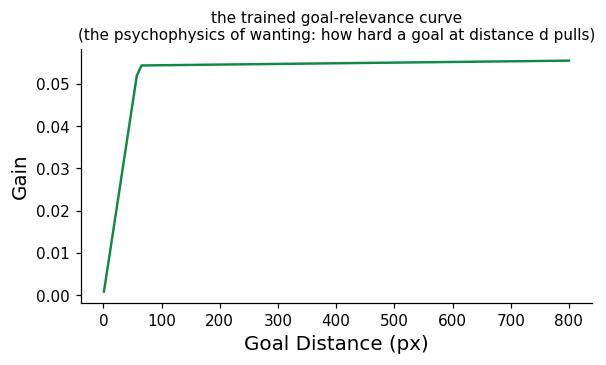

In [10]:
with torch.no_grad():
    d_axis = torch.linspace(1, 800, 100).unsqueeze(1)
    g_curve = model.goal_gain(d_axis / model.sensing_range).squeeze(1).numpy()
plt.figure(figsize=(6, 3))
plt.plot(d_axis.squeeze(1).numpy(), g_curve, color=C_GOAL)
plt.xlabel("Goal Distance (px)", fontsize=13); plt.ylabel("Gain", fontsize=13)
plt.title("the trained goal-relevance curve\n"
          "(the psychophysics of wanting: how hard a goal at distance d pulls)",
          fontsize=10)
plt.show()


## 5. How good is it?

The evaluation of record mirrors the demonstrations exactly: a
persistent world, unbiased goals, a new goal on every arrival —
scored as **goals per minute** and **collisions per minute**, against
the expert's own 65.8 and 0.0. (Two seeds here for speed; the
three-seed comparison sweep in Section 6: 60.3 goals/min, 0.0
collisions/min — the clone matches its teacher.)

In [11]:
from evaluate_goal_es2 import run_seed as eval_run_seed

def eval_args(**over):
    base = dict(num_features=360, num_actions=2, sensing_range=800.0,
                num_balls=10, width=W, height=H, max_speed=10.0,
                max_steps=6000, goal_free_steps=0, goal_timeout=300,
                goal_bias="none", bias_p=0.8, min_spawn_dist=250,
                speed_multiplier=1.0, respawn_center=False,
                spawn_from_center=False)
    base.update(over)
    return SimpleNamespace(**base)

rows = [eval_run_seed(model, eval_args(), 42 + i) for i in range(2)]
g = np.mean([r["goals_per_min"] for r in rows])
c = np.mean([r["collisions_per_min"] for r in rows])
print(f"model:  {g:.1f} goals/min, {c:.1f} collisions/min")
print("expert: 65.8 goals/min, 0.0 collisions/min")

model:  59.0 goals/min, 0.0 collisions/min
expert: 65.8 goals/min, 0.0 collisions/min


## 6. Does it generalize? Comparison against baselines

The demonstrations contain exactly one regime: 10 balls at speeds 1-3
px/step. Two stress axes probe what the learned field does outside it:

- **Density**: up to 50 balls, several times the crowding ever
  demonstrated.
- **Speed**: multiplying every ball's velocity, up to 4x.

And the field model does not stand alone: the repository's two
goal-conditioned baselines — an MLP over the raw 722-vector and a
transformer over it as a token sequence — were trained on the SAME
demonstrations with the SAME recipe (batch 64, Adam, MSE, 500 epochs)
and swept over the same conditions. The cell below loads all three
models' recorded results (`results_compare/`; ES2 is the additive
model of record, the baselines are the recorded cluster runs) and plots
cloning loss and rollout across the two stress axes. (The transformer
needed a GPU — L40S, ~38 h projected on CPU — so its wall-clock is not
hardware-comparable; the loss-by-epoch axis is.)

all three trained 500 epochs (= 94,000 updates), same recipe:
  goal ES2 (field model)   final MSE  0.081   wall-clock local CPU, 500 ep   rollout 60.3 goals/min, 0.0 collisions/min
  goal MLP                 final MSE  0.111   wall-clock 7:25 (8 CPUs)   rollout 38.0 goals/min, 2.2 collisions/min
  goal transformer         final MSE  3.593   wall-clock 45:44 (L40S GPU)   rollout 53.5 goals/min, 0.0 collisions/min


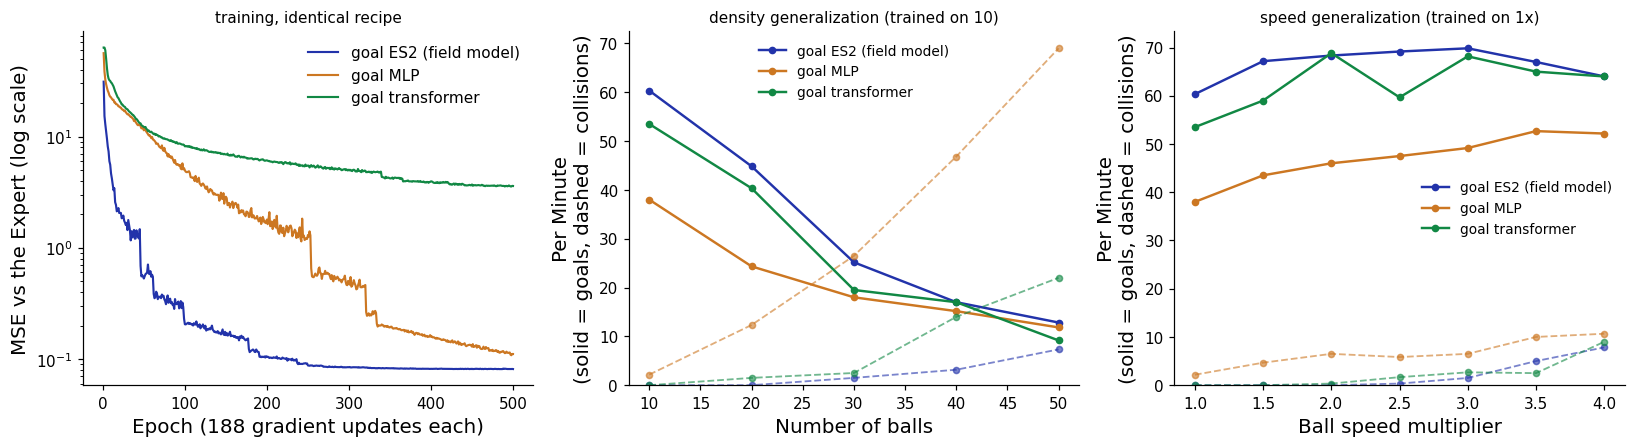

In [12]:
# ES2 is the additive model of record (trained locally, 500 epochs); the MLP
# and transformer baselines are the recorded cluster runs on identical footing
# (500 epochs, same recipe). No training happens in this notebook.
import csv
import glob

import matplotlib.pyplot as plt

colors = {"es2": C_ES2, "mlp": C_MLP, "transformer": C_TRF}
labels = {"es2": "goal ES2 (field model)", "mlp": "goal MLP",
          "transformer": "goal transformer"}

loss = {}
for m in colors:
    with open(f"results_compare/loss_goal_{m}.csv") as f:
        loss[m] = [float(r["loss"]) for r in csv.DictReader(f)]

rows = []
for f in glob.glob("results_compare/sweep_*.csv"):
    with open(f) as fh:
        rows += list(csv.DictReader(fh))

def curve(m, key, fixed, x_key):
    pts = sorted((float(r[x_key]), float(r[key])) for r in rows
                 if r["model"] == m
                 and all(float(r[k]) == v for k, v in fixed.items()))
    return [p[0] for p in pts], [p[1] for p in pts]

print("all three trained 500 epochs (= 94,000 updates), same recipe:")
for m, wall in [("es2", "local CPU, 500 ep"), ("mlp", "7:25 (8 CPUs)"),
                ("transformer", "45:44 (L40S GPU)")]:
    x, g = curve(m, "goals_per_min", {"num_balls": 10}, "speed_multiplier")
    _, c = curve(m, "collisions_per_min", {"num_balls": 10}, "speed_multiplier")
    print(f"  {labels[m]:<24} final MSE {loss[m][-1]:6.3f}   wall-clock {wall}"
          f"   rollout {g[0]:.1f} goals/min, {c[0]:.1f} collisions/min")

fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))
ax = axes[0]
for m in colors:
    ax.plot(range(1, len(loss[m]) + 1), loss[m], color=colors[m], lw=1.4,
            label=labels[m])
ax.set_yscale("log")
ax.set_xlabel("Epoch (188 gradient updates each)", fontsize=13)
ax.set_ylabel("MSE vs the Expert (log scale)", fontsize=13)
ax.set_title("training, identical recipe", fontsize=10)
ax.legend()
for ax, x_key, fixed, xlab, ttl in [
        (axes[1], "num_balls", {"speed_multiplier": 1.0}, "number of balls",
         "density generalization (trained on 10)"),
        (axes[2], "speed_multiplier", {"num_balls": 10}, "ball speed multiplier",
         "speed generalization (trained on 1x)")]:
    for m in colors:
        x, g = curve(m, "goals_per_min", fixed, x_key)
        _, c = curve(m, "collisions_per_min", fixed, x_key)
        ax.plot(x, g, "o-", color=colors[m], lw=1.6, ms=4, label=labels[m])
        ax.plot(x, c, "o--", color=colors[m], lw=1.2, ms=4, alpha=0.6)
    ax.set_xlabel(xlab.capitalize(), fontsize=13)
    ax.set_ylabel("Per Minute\n(solid = goals, dashed = collisions)", fontsize=13)
    ax.set_title(ttl, fontsize=10)
    ax.set_ylim(bottom=0)
    ax.legend(fontsize=9)
plt.tight_layout()
plt.show()


Three readings, honestly stated. First,
imitation loss does not predict rollout: the transformer ends ~44x above
the field model's MSE yet behaves respectably in closed loop (its
per-step errors average out), while the MLP's near-equal MSE hides
systematically unsafe avoidance. Second, what separates the
architectures under stress is **safety**, not throughput — at 50 balls
all three land at roughly 9-13 goals/min, but collisions run 7.3 (field),
22.0 (transformer), 69.0 (MLP) per minute. Third, the field model wins
overall — best fit, best trained-regime throughput (60.3 goals/min vs
53.5 and 38.0), most graceful degradation on both axes — while being
the only architecture whose internals are interpretable fields: the
psychophysics of Section 2, the channel decomposition, and the
selection-history mechanism of Section 7 have no analog in the
baselines.

## 7. Selection history: statistical learning of likely locations

### 7a. Why the clone has none — and why that is correct

The search model's history parameters were **fitted to humans**, and
humans carry selection history. Here the "participant" is a scripted
expert that never consults its memory — so behavioral cloning
*correctly* finds nothing for the history channel to explain (the full
negative record is in `RESULTS_goal_es2.md`). History must therefore
enter the way the search model itself adds it: a small parametric
mechanism **on top of** the competent machinery.

### 7b. The mechanism: a leaky map, read out egocentrically

The memory is a leaky accumulator over an 8x8 grid of the arena in
**world coordinates** — at each goal spawn every weight decays by
`(1 - eta)` and the goal's cell gains `eta` — so the agent remembers
*where goals tend to appear* no matter where it moves. The readout
converts to the agent's frame through the **trained goal machinery**:

    history_field = beta_H * sum_c W[c] * geometric_field(center_c - position, goal_gain)

Allocentric storage, egocentric readout. The priority-field formula is
unchanged (obstacle + goal + `beta_H` x history), one precedence rule
completes it — **a visible goal overrides history** (the history field
feeds the map only during goal-free anticipation windows) — and the
one-back trace used for target-location priming (`evaluate_priming.py`,
recorded in the ledger) is the `eta = 1` degenerate case of this same
memory. `eta` is the learning rate, the grid is what is remembered,
`beta_H` is how strongly memory biases the field.

### 7c. The demonstration: retrain, deploy, watch the bias live and die

Trials are fixation-start (teleport to center, a 50-step goal-free
window, then the goal) with goals at matched eccentricity: 70% in a
90-degree wedge due-left, 30% in the mirror wedge due-right. Three
stages, imported from `evaluate_statistical_learning.py`:

1. **Teacher**: the trained checkpoint equipped with the grid at ground
   truth `beta* = 0.2, eta* = 0.15` plays the biased task; its
   goal-free behavior is recorded.
2. **Retrain**: a fresh copy with **every network weight frozen**; only
   the two history scalars are trained on those rows, the grid replayed
   differentiably under the candidate `eta` (the agent-side analog of
   the search model's history fitting). Teacher and student share the
   network, so recovery is exact-units.
3. **Deploy**: the fitted student in a world biased for the first 90
   trials and unbiased after — watching the drift bias **emerge** from
   experienced goals and **extinguish** once the statistics change.


teacher (beta*=0.2, eta*=0.15): 1990 goal-free rows, drift +0.95 px/step


recovered: beta_hat = 0.200 (true 0.2), eta_hat = 0.150 (true 0.15), residual MSE 0.713


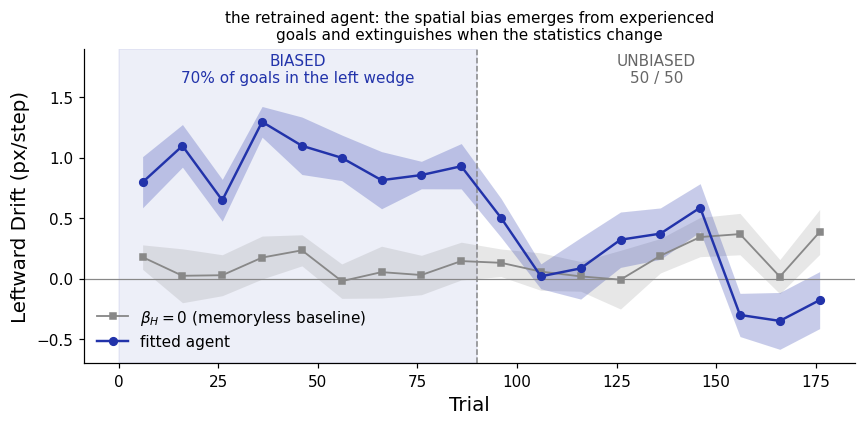

In [13]:
from evaluate_statistical_learning import play, fit_history_params

sargs = SimpleNamespace(num_features=360, num_balls=10, width=W, height=H,
                        max_speed=10.0, goal_timeout=300, goal_free_steps=50,
                        record_every=5, ecc_min=250.0, ecc_max=330.0,
                        p_high=0.7)
BETA_STAR, ETA_STAR = 0.2, 0.15
for p_ in model.parameters():
    p_.requires_grad = False

# 1. teacher: ground-truth memory parameters, biased world
rows, goal_seq, tdrifts = play(model, BETA_STAR, ETA_STAR, seed=42,
                               n_trials=200, biased_until=200, args=sargs,
                               record_rows=True)
td = [d for d in tdrifts if not math.isnan(d)]
print(f"teacher (beta*={BETA_STAR}, eta*={ETA_STAR}): {len(rows)} goal-free "
      f"rows, drift {sum(td)/len(td):+.2f} px/step")

# 2. retrain: ONLY (beta_H, eta), policy frozen
beta_hat, eta_hat, mse = fit_history_params(model, rows, goal_seq, sargs,
                                            verbose=False)
print(f"recovered: beta_hat = {beta_hat:.3f} (true {BETA_STAR}), "
      f"eta_hat = {eta_hat:.3f} (true {ETA_STAR}), residual MSE {mse:.3f}")

# 3. deploy the fitted student: bias on for 90 trials, then 50/50
SWITCH, N_DEP, SEEDS, CTRL_SEEDS = 90, 180, 10, 6
curves = []
for i in range(SEEDS):
    _, _, drifts = play(model, beta_hat, eta_hat, seed=100 + i,
                        n_trials=N_DEP, biased_until=SWITCH, args=sargs)
    curves.append(drifts)
# beta = 0 control: the memoryless base policy on the same protocol.
# Its goal-free drift is NOT exactly zero - the zero-goal input never
# occurs in the cloning data, so the network's output there is an
# unconstrained residual - and this line is what "extinguished" should
# be compared against.
ctrl = []
for i in range(CTRL_SEEDS):
    _, _, drifts = play(model, 0.0, eta_hat, seed=100 + i,
                        n_trials=N_DEP, biased_until=SWITCH, args=sargs)
    ctrl.append(drifts)

BLOCK = 10
def blocked(cs):
    xs_, m_, s_ = [], [], []
    for b0 in range(1, N_DEP, BLOCK):
        per_seed = [np.mean([c[t] for t in range(b0, min(b0 + BLOCK, N_DEP))
                             if not math.isnan(c[t])]) for c in cs]
        xs_.append(b0 + BLOCK / 2)
        m_.append(np.mean(per_seed))
        s_.append(np.std(per_seed, ddof=1) / math.sqrt(len(cs)))
    return xs_, np.array(m_), np.array(s_)
xs, mean, sem = blocked(curves)
_, cmean, csem = blocked(ctrl)

fig, ax = plt.subplots(figsize=(8, 4))
ax.axvspan(0, SWITCH, color=C_ES2, alpha=0.08)
ax.axvline(SWITCH, color=C_GRAY, lw=1, ls="--")
ax.axhline(0, color=C_GRAY, lw=0.8)
ax.fill_between(xs, cmean - csem, cmean + csem, color=C_GRAY, alpha=0.2, lw=0)
ax.plot(xs, cmean, "s-", color=C_GRAY, ms=4, lw=1.2,
        label=r"$\beta_H = 0$ (memoryless baseline)")
ax.fill_between(xs, mean - sem, mean + sem, color=C_ES2, alpha=0.25, lw=0)
ax.plot(xs, mean, "o-", color=C_ES2, ms=5, label="fitted agent")
ax.legend(loc="lower left")
ax.text(SWITCH / 2, 1.62, "BIASED\n70% of goals in the left wedge",
        ha="center", fontsize=10, color=C_ES2)
ax.text((SWITCH + N_DEP) / 2, 1.62, "UNBIASED\n50 / 50", ha="center",
        fontsize=10, color="#666666")
ax.set_xlabel("Trial", fontsize=13)
ax.set_ylabel("Leftward Drift (px/step)", fontsize=13)
ax.set_ylim(-0.7, 1.9)
ax.set_title("the retrained agent: the spatial bias emerges from experienced\n"
             "goals and extinguishes when the statistics change", fontsize=10)
plt.tight_layout()
plt.show()


Three results in one chain (ledger, `evaluate_statistical_learning.py`).
**Recovery is exact**: with the network frozen, the two history scalars
fitted on the teacher's goal-free drift land on the generating values
(the ledger record: 0.200 / 0.150; the residual MSE is integer-stepping
noise) — the parameters are identifiable from behavior, as in the
search model's fits. **The bias emerges**: deployed in the biased
world, the fitted agent's goal-free drift toward the likely region
builds over ~30 trials to a ~1 px/step plateau, purely from
experienced goal locations — the grid starts empty. **And it
extinguishes**: after the switch to unbiased statistics the learned
drift decays within ~1/eta goals down to the gray `beta_H = 0`
baseline — the memoryless policy's own goal-free residual, which is
not exactly zero because the zero-goal input never occurs in the
cloning data, so the network's output there is unconstrained (a small
push, mostly downward, whose closed-loop horizontal component comes
out slightly rightward). Extinguished means indistinguishable from
the memoryless agent, and that baseline — not the zero line — is the
comparison. It is genuinely statistical learning, not priming
in disguise: on trials where the previous goal fell in the unlikely
wedge, the grid agent still drifts toward the likely region while the
one-back trace (the `eta = 1` case) drifts the wrong way (ledger).
Honest boundaries: the mechanism is endowed and its parameters fitted
— the statistics are what is acquired; and human location-probability
cueing extinguishes far more slowly than a single-eta leak (Jiang's
persistence findings), so habit-like persistence would need a second,
slower accumulator.

## Recap

| The agent receives | It returns |
| --- | --- |
| two LiDAR scans, the goal vector, the remembered-goal vector | a 2D movement |

We introduced the field model and its diagram (Sec. 1), built the
pieces - distance psychophysics, looming, the gain-x-cosine goal and
history fields (Sec. 2) - showed the whole forward pass imported from
the codebase (Sec. 3), cloned the expert with history disabled
(Sec. 4), matched the expert's throughput on the task of record
(Sec. 5), probed never-demonstrated densities and speeds and compared the field
model against MLP and transformer baselines trained on identical
footing (Sec. 6),
and closed the chain on selection history: a leaky world-grid memory
whose two parameters are recoverable from demonstrations with the
policy frozen, and whose deployment shows a spatial bias emerging from
experienced goal statistics and extinguishing when they change
(Sec. 7; the one-back priming demonstration it generalizes is recorded
in the ledger and `evaluate_priming.py`).

More: `RESULTS_goal_es2.md` (the full experimental record for
this model) and `Visual-Search/tutorial_visual_search.ipynb` (the
companion model of first saccades).